# 1. Arctic Oscillation

/opt/anaconda3/lib/python3.12/site-packages/xarray/core/computation.py:761: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


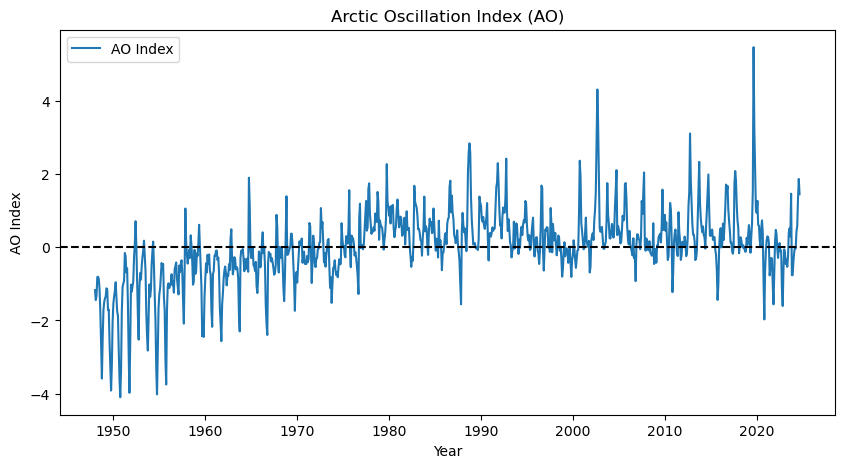

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from eofs.standard import Eof




file_path = "hgt_monmean.nc"
ds = xr.open_dataset(file_path)
height_anomalies = ds['hgt']  


monthly_mean = height_anomalies.groupby('time.month').mean('time')
deseasonalized_anomalies = height_anomalies.groupby('time.month') - monthly_mean


latitudes = ds['lat']
weights = np.sqrt(np.cos(np.deg2rad(latitudes)))
weighted_anomalies = deseasonalized_anomalies * weights


solver = Eof(weighted_anomalies.values)
eof1 = solver.eofs(neofs=1)  
pc1 = solver.pcs(npcs=1, pcscaling=1)  


ao_index = (pc1 - np.mean(pc1)) / np.std(pc1)


plt.figure(figsize=(10, 5))
plt.plot(ds['time'], ao_index, label="AO Index")
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Year")
plt.ylabel("AO Index")
plt.title("Arctic Oscillation Index (AO)")
plt.legend()
plt.show()


In [2]:
ao_index

array([[-1.17402005e+00],
       [-1.44254887e+00],
       [-1.32819676e+00],
       [-8.16164553e-01],
       [-8.05221975e-01],
       [-8.75531793e-01],
       [-1.16390789e+00],
       [-1.79188430e+00],
       [-2.73943686e+00],
       [-3.58670831e+00],
       [-2.48874903e+00],
       [-1.72482061e+00],
       [-1.49288976e+00],
       [-1.39464915e+00],
       [-1.34166074e+00],
       [-1.12166739e+00],
       [-1.15804780e+00],
       [-1.71613884e+00],
       [-1.69915819e+00],
       [-2.60851598e+00],
       [-3.27989674e+00],
       [-3.91338086e+00],
       [-3.21787024e+00],
       [-2.02037740e+00],
       [-1.53216374e+00],
       [-1.32628441e+00],
       [-1.19597542e+00],
       [-9.54722404e-01],
       [-1.37925243e+00],
       [-1.76178730e+00],
       [-1.86933923e+00],
       [-2.80787635e+00],
       [-3.59562135e+00],
       [-4.09569120e+00],
       [-3.38808131e+00],
       [-1.76321447e+00],
       [-1.08042371e+00],
       [-9.87030149e-01],
       [-9.1

# 2. Antarctic Oscillation

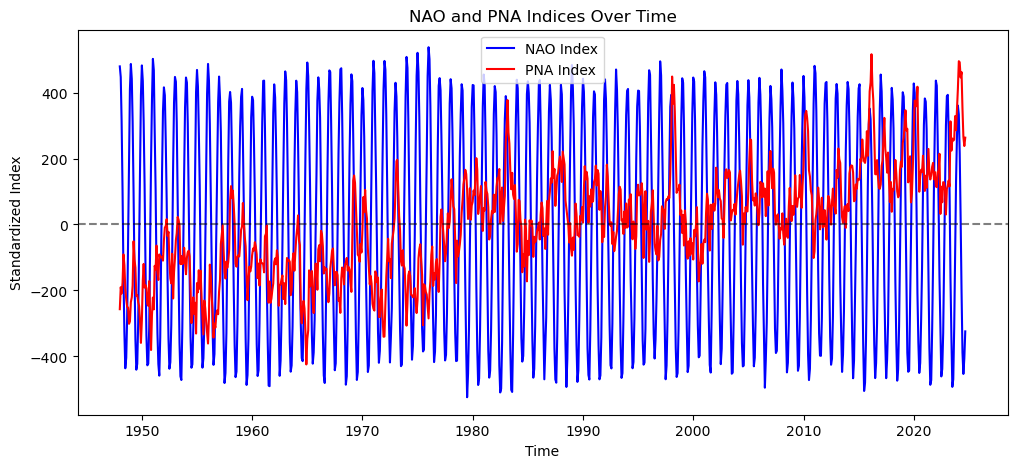

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from eofs.standard import Eof
from sklearn.decomposition import PCA


file_path = "hgt_monmean.nc"
ds = xr.open_dataset(file_path)
height_anomalies = ds['hgt']  


climatology_mean = height_anomalies.sel(time=slice("1950", "2000")).mean(dim='time')
climatology_std = height_anomalies.sel(time=slice("1950", "2000")).std(dim='time')
standardized_anomalies = (height_anomalies - climatology_mean) / climatology_std


reshaped_data = standardized_anomalies.values.reshape(len(standardized_anomalies.time), -1)  # Flatten spatial dims
pca = PCA(n_components=4)  
pcs = pca.fit_transform(reshaped_data)


nao_index = pcs[:, 0] 
pna_index = pcs[:, 1]  


plt.figure(figsize=(12, 5))
plt.plot(standardized_anomalies.time, nao_index, label='NAO Index', color='b')
plt.plot(standardized_anomalies.time, pna_index, label='PNA Index', color='r')
plt.axhline(0, linestyle='--', color='k', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Standardized Index')
plt.title('NAO and PNA Indices Over Time')
plt.legend()
plt.show()


In [4]:
nao_index = pcs[:, 0]  
pna_index = pcs[:, 1]